<a href="https://colab.research.google.com/github/engcriscunha/avanti-bean-leaf-classification/blob/main/execu%C3%A7%C3%A3o_notebook_akhilchibber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Execução do notebook

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

### 1. Baixar o Dataset do Kaggle

In [2]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.6 MB/s eta 0:00:00


In [3]:
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eng.criscunha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 98.3MB/s]


In [4]:
!ls

bean-leaf-lesions-classification  sample_data


In [5]:
import cv2
import os

In [6]:
root_dir = './bean-leaf-lesions-classification'

In [7]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['train.csv', 'classname.txt', 'val', 'train', 'val.csv']


### **1.1 Import Libraries**
We begin by importing necessary Python libraries. These libraries help us with data manipulation (pandas, numpy), handling images (PIL, matplotlib), and more.

In [8]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob

### **1.2 Load and Organize the Data**
We need to load the images and their corresponding labels. The data consists of images in different folders, each representing a class (healthy, angular_leaf_spot, bean_rust).

In [9]:
# Create dataframes to hold paths and labels
train_df = pd.DataFrame({"path":[], "label":[], "class_id":[]})
val_df = pd.DataFrame({"path":[], "label":[], "class_id":[]})

In [10]:
# Define the path to the training and validation data
train_path = "./bean-leaf-lesions-classification/train"
val_path = "./bean-leaf-lesions-classification/val"

In [11]:
# Define a dictionary to map labels to numeric ids
label_dict = {"healthy": 0, "angular_leaf_spot": 1, "bean_rust": 2}

In [12]:
# Function to load images and labels into the dataframe
def load_images(path, label_dict):
    df = pd.DataFrame({"path":[], "label":[], "class_id":[]})
    folder_list = os.listdir(path)
    for folder in folder_list:
        img_path = os.path.join(path, folder)
        jpg_list = glob(img_path + '/*.jpg')
        for jpg in jpg_list:
            new_data = pd.DataFrame({"path": [jpg], "label": [folder], "class_id": [label_dict[folder]]})
            df = pd.concat([df, new_data], ignore_index=True)
    return df

In [13]:
# Load training and validation data
train_df = load_images(train_path, label_dict)
val_df = load_images(val_path, label_dict)

### **1.3 Data Visualization**
It's often useful to visualize some of the data. Here, we'll randomly select and display a few images from the training set.

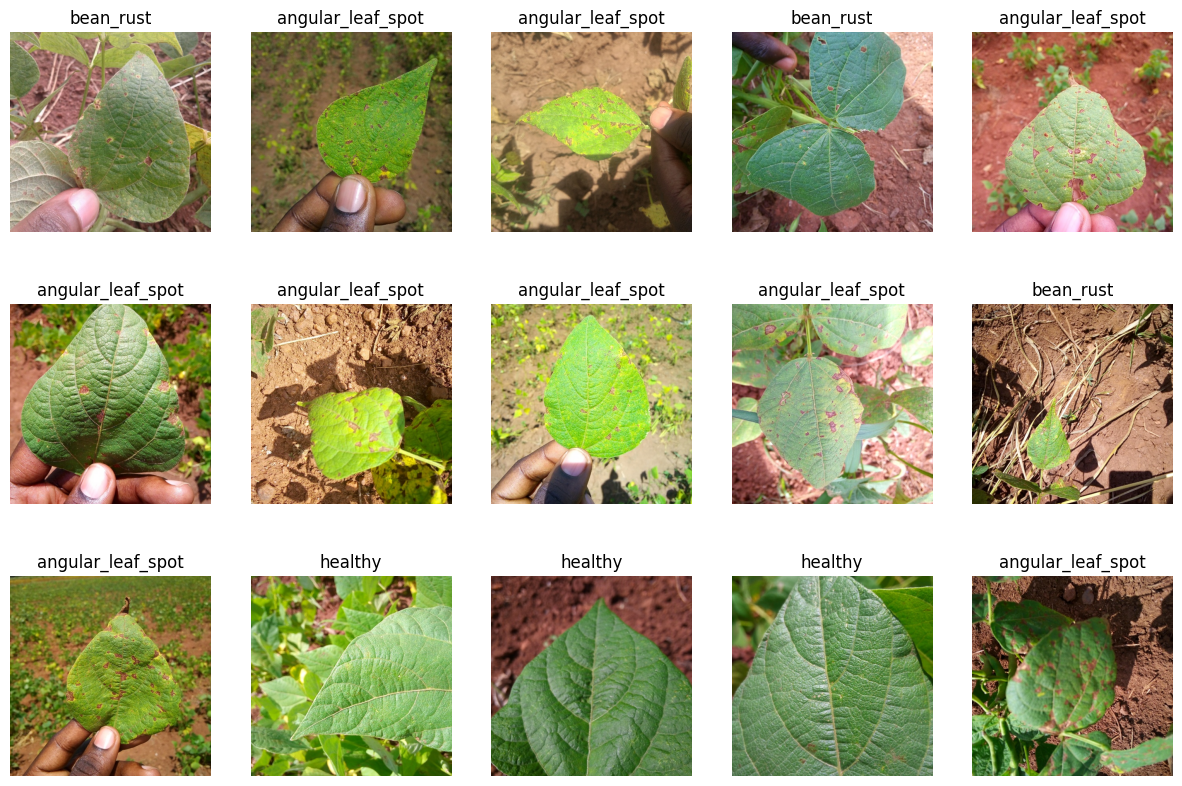

In [14]:
show_imgs = 15
idx = np.random.randint(0, len(train_df), size=show_imgs)
fig, axes = plt.subplots(show_imgs // 5, 5, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    full_path = train_df.loc[idx[i]]['path']
    ax.imshow(plt.imread(full_path))
    ax.set_title(train_df.loc[idx[i]]['label'])
    ax.set_axis_off()

plt.show()

### **1.4 Data Transformation and Augmentation**
We'll use PyTorch's transforms for preprocessing and augmenting the images. This step is crucial for deep learning models to generalize better.

In [15]:
# Data Transformation and Augmentation
import torchvision.transforms as transforms

# Define transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    # Other transformations can be added here
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### **1.5 Create Custom Dataset**
We create a custom dataset class that extends PyTorch's Dataset. This class will handle loading images and applying the transformations.

In [16]:
# Create Custom Dataset
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, dataframe, transforms_):
        self.df = dataframe
        self.transforms_ = transforms_

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        image_path = self.df.iloc[index]['path']
        img = Image.open(image_path).convert("RGB")
        transformed_img = self.transforms_(img)
        class_id = self.df.iloc[index]['class_id']
        return transformed_img, class_id

### **1.6 Create DataLoaders**
Finally, we set up PyTorch DataLoaders for both the training and validation datasets. DataLoaders allow efficient loading and batching of data during training.

In [17]:
# Create DataLoaders
from torch.utils.data import DataLoader

train_dataset = MyDataset(train_df, train_transforms)
val_dataset = MyDataset(val_df, val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

This completes the Data Preparation step. Next, we'll move on to building the model.

# **Step 2: Model Building**
In this section, we"ll focus on setting up the deep learning model. It will cover the part of the script where the neural network model is loaded (using PyTorch's pre-trained models) and modified for the specific classification task. This includes the creation of the MyDataset class and the modification of the model's classifier layer.

### **2.1 Import Necessary Libraries**
First, we need to import the necessary components from PyTorch.

In [18]:
import torch
import torch.nn as nn
from torchvision import models

### **2.2 Define the Model**
We will use a pre-trained model and modify its final layer to suit our classification task, which has three classes (healthy, angular_leaf_spot, bean_rust).

In [19]:
# Define the number of classes
num_classes = 3

# Load a pre-trained model
model = models.efficientnet_v2_s(pretrained=True)

# Modify the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Print the Deep Learning model architecture
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 101MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

### **2.3 Set the Device**
We need to set the device to either CPU or GPU (if available) for training.

In [20]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the chosen device
model = model.to(device)

### **2.4 Print Model Summary**


In [21]:
!pip install torchsummary

In [22]:
from torchsummary import summary

# Print the model summary (for input size [3, 224, 224])
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

This completes the model building step. We have successfully loaded a pre-trained EfficientNet model and adapted it for our three-class classification task. The model is now ready to be trained on our bean leaf lesions dataset.

# **Step 3: Model Training and Validation**
This part will encompass the training loop and the functions needed for training (train) and validation (test). It will detail the steps of the training process, including setting up the loss function, optimizer, learning rate scheduler, and the training loop itself, which includes early stopping.

### **3.1 Import Necessary Libraries**
First, we need to ensure that all necessary libraries are imported.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from tqdm import tqdm

### **3.2 Define Loss Function, Optimizer, and Learning Rate Scheduler**
Before training, we define the loss function, the optimizer, and the learning rate scheduler.

In [24]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (using AdamW here)
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Learning rate scheduler (optional)
lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

### **3.3 Training and Validation Functions**
Define the functions for training and validating the model.

In [25]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device).long()

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save the metrics as Python numbers
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())  # Convert to Python number
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())  # Convert to Python number

    print('Training complete')

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

### **3.4 Train the Model**
Now, we use the defined functions to train and validate our model. Set the number of epochs as per your requirement.

In [26]:
model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(model, criterion, optimizer, lr_scheduler, num_epochs=25)

Epoch 1/25
----------
train Loss: 0.8143 Acc: 0.6712
val Loss: 0.3417 Acc: 0.9323
Epoch 2/25
----------
train Loss: 0.3071 Acc: 0.9033
val Loss: 0.1402 Acc: 0.9549
Epoch 3/25
----------
train Loss: 0.1976 Acc: 0.9362
val Loss: 0.1108 Acc: 0.9699
Epoch 4/25
----------
train Loss: 0.1372 Acc: 0.9487
val Loss: 0.0860 Acc: 0.9699
Epoch 5/25
----------
train Loss: 0.1492 Acc: 0.9478
val Loss: 0.0381 Acc: 0.9925
Epoch 6/25
----------
train Loss: 0.0952 Acc: 0.9681
val Loss: 0.0439 Acc: 0.9850
Epoch 7/25
----------
train Loss: 0.1128 Acc: 0.9603
val Loss: 0.0683 Acc: 0.9774
Epoch 8/25
----------
train Loss: 0.0880 Acc: 0.9691
val Loss: 0.0568 Acc: 0.9850
Epoch 9/25
----------
train Loss: 0.0872 Acc: 0.9691
val Loss: 0.0756 Acc: 0.9774
Epoch 10/25
----------
train Loss: 0.0895 Acc: 0.9662
val Loss: 0.0501 Acc: 0.9850
Epoch 11/25
----------
train Loss: 0.0885 Acc: 0.9710
val Loss: 0.0742 Acc: 0.9774
Epoch 12/25
----------
train Loss: 0.0815 Acc: 0.9739
val Loss: 0.0630 Acc: 0.9850
Epoch 13/25
-

In [27]:
# Save the model
torch.save(model.state_dict(), "./bean-leaf-lesions-classification/model.pth")

### **3.5 Plotting the Metrics**
After training, we will use matplotlib to plot the loss and accuracy during model training in a graph.

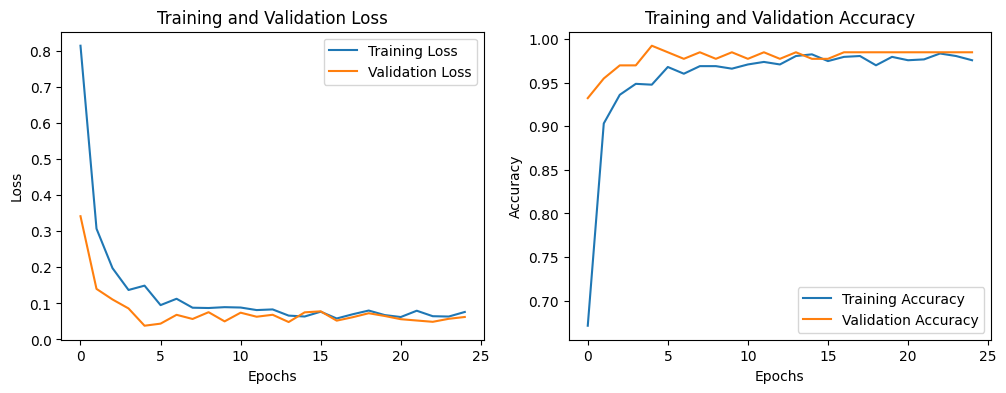

In [28]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

This concludes the Model Training and Validation step. In this phase, we trained our model on the training dataset and evaluated its performance on the validation dataset. The model's weights are updated to learn from the training data, and its accuracy and loss are monitored to ensure proper learning. Next, in Step 4, we will evaluate our trained model's performance in more detail, particularly on the validation set.

# **Step 4: Model Evaluation**
Here, we"ll focus on loading the best model and evaluating its performance on the validation dataset. This part will cover the script sections where the model is loaded from the saved state (best.pth), and the model's performance is evaluated using the validation dataset.

### **4.1 Evaluate the Model**
First, we'll create a function to evaluate the model. This function will use the validation dataset to predict labels and then compare them with the true labels.

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track the gradients
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Evaluate the model
all_labels, all_preds = evaluate_model(model, val_loader)

### **4.2 Classification Report and Accuracy**
We'll generate a classification report and calculate the accuracy.